<a href="https://colab.research.google.com/github/digitalchessman-tech/data-science-ipython-notebooks/blob/master/Ejemplo_1_UA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("salary_data.csv")


<Axes: title={'center': 'Evolucion del Salario segun los Años de Experiencia'}, xlabel='YearsExperience'>

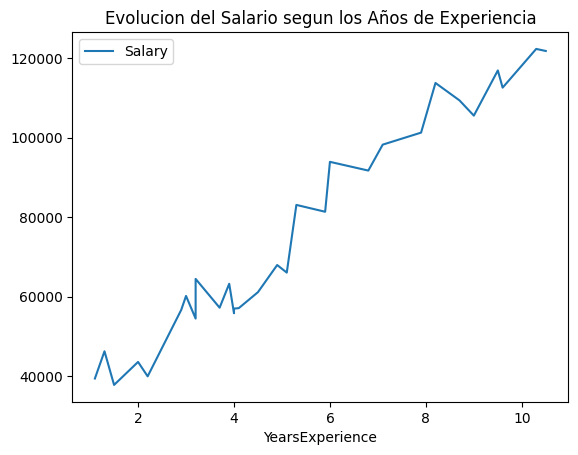

In [ ]:
df.plot(x="YearsExperience", y="Salary", title="Evolucion del Salario segun los Años de Experiencia")

Usaremos un modelo de regresión simple :   y = b1 * x

In [ ]:
# separacion en variables de entrada /salida
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
# hacemos el split de train/ test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

# y con ello se construye el modelo, usando la libreria "statsmodels"
import statsmodels.api as sm
model = sm.OLS (y_train, X_train).fit()
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.965
Model:                            OLS   Adj. R-squared (uncentered):              0.963
Method:                 Least Squares   F-statistic:                              525.3
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                    2.64e-15
Time:                        16:48:41   Log-Likelihood:                         -219.36
No. Observations:                  20   AIC:                                      440.7
Df Residuals:                      19   BIC:                                      441.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Comprobaciones de la hipotesis del modelo de regresion lineal

In [ ]:
# Linealidad

import statsmodels.stats.api as sms
sms.linear_harvey_collier(model)


TtestResult(statistic=np.float64(1.137603959747104), pvalue=np.float64(0.272035496366901), df=np.int64(16))

el p-value es 0.272 > 0.05 por lo tanto no se rechaza la hipotesis que dice que hay linealidad

(array([0., 0., 2., 0., 3., 6., 5., 3., 1., 0.]),
 array([-45000., -36000., -27000., -18000.,  -9000.,      0.,   9000.,
         18000.,  27000.,  36000.,  45000.]),
 <BarContainer object of 10 artists>)

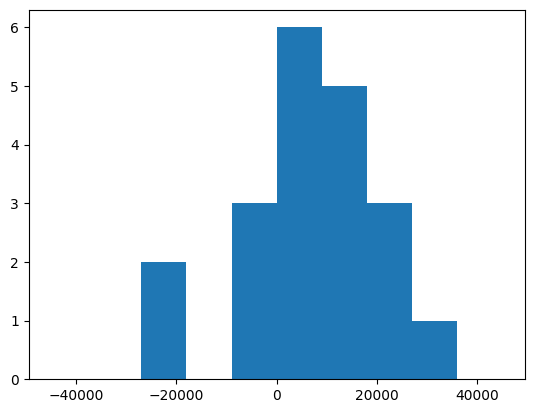

In [ ]:
# Normalidad de residuos
# Obtención de residuos

from statsmodels.compat import lzip
residuos = model.resid

# Histogramas

plt.hist(residuos, range = (-45000, 45000))

Veamos ahora en forma de Q-Q plot

0.9576407903030612


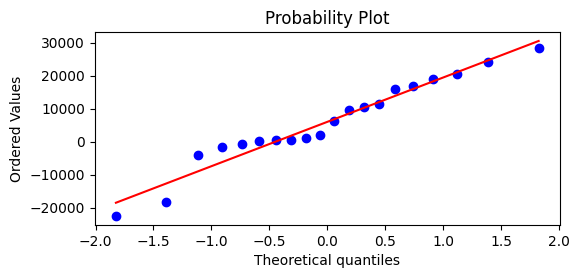

In [ ]:
# Q-Q plot

import scipy as sp
fig, ax = plt.subplots(figsize = (6, 2.5))
_, (_,__,r) = sp.stats.probplot(residuos, plot = ax, fit=True)
print(r**2)


Cuanto más cercano a 1, más se parecerán las distribuciones. En este caso el valor es **0.957**, muy cercano a 1, con lo cual se puede decir que los residuos tienen una distribución normal.

Podemos también comprobarlo con el test D'Agostino


In [ ]:
# Test D' Agostino
from scipy.stats import normaltest
normaltest(residuos)

NormaltestResult(statistic=np.float64(0.8087058796668815), pvalue=np.float64(0.6674085246421335))

se obtiene un p-value 0.667 muy superior a 0.05 con lo cual NO SE RECHAZA la H0 que dice que los datos son normales.

In [ ]:

# Comprobación de Homocedasticidad
# Goldfeld-Quandt test

import statsmodels.stats.api as sms
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(model.resid, model.model.exog)
lzip (name, test)

[('F statistic', np.float64(0.5867790225429672)),
 ('p-value', np.float64(0.7803560112163154))]

el resultado muestra p-value = 0.78 lo cual es mucho mayor que 0.05 (alpha de contraste) por lo que no se puede rechazar la H0 que dice que hay Homocedasticidad.

Tambien se puede hacer una inspección visual, observando como se distribuyen los residuos frente al valor del predictor

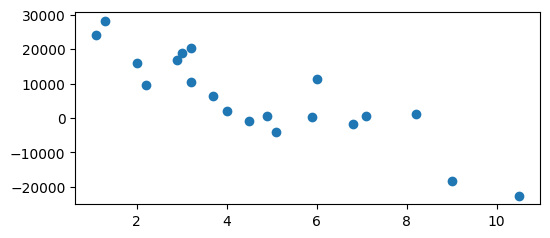

In [ ]:
fig, ax = plt.subplots(figsize = (6, 2.5))
_ = ax.scatter (X_train, residuos)


Claramente no hay Heterocedasticidad pero aparece una situación potencialmente alarmante, los residuos no tienen una distribución aleatoria, habría que ver de mejorar el modelo.

In [ ]:
# Autocorrelación de residuos

from statsmodels.stats.stattools import durbin_watson
print(durbin_watson(residuos))


2.455674965484638


ese valor cercano a 2 es un buen resultado. En realidad 2.45 muestra una leve correlacion negativa pero aceptable.

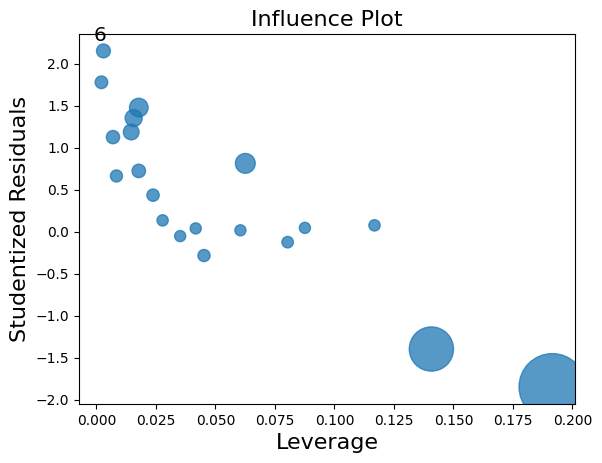

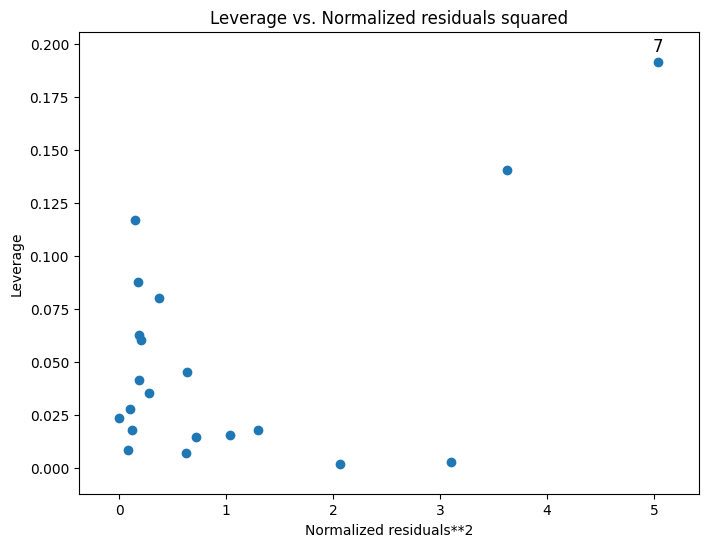

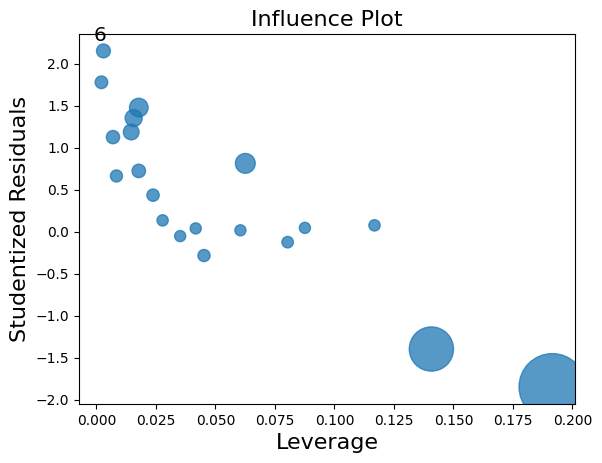

In [ ]:
# Leverage (puntos palanca)
# Comprobacion de influencia de posibles outliers

from statsmodels.stats.outliers_influence import OLSInfluence
model = sm.OLS(y_train, X_train).fit()
test_class = OLSInfluence(model)
test_class.dfbetas[:5,:]

# Df Betas de la diferencia en cada parámetro estimado
# con o sin puntos de influencia

from statsmodels.graphics.regressionplots import plot_leverage_resid2, influence_plot
fig, ax = plt.subplots(figsize = (8, 6))
fig = plot_leverage_resid2(model, ax = ax)
influence_plot(model)


Hay que tener cuidado con las observaciones de leverage alto y con los residuos altos. En el diagrama de influencia no se observa nada en el cuadrante superior derecho, pero en el de residuos si aparece uno. la Observación 7, hay que tener precaución. Pero como es un ejercicio y un modelo de prueba no tomaremos acciones.

Contodo esto verificado podemos pasar a las predicciones del modelo.

In [ ]:
# Predicciones del modelo

y_pred = model.predict(X_test)

# Métricas de evaluación

from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score (y_test, y_pred)
mae = mean_squared_error(y_test, y_pred)
print("r2: ", r2, "mae:", mae)

r2:  0.8111465166115929 mae: 158298192.73508132


R2 es un valor entre 0 y 1 que remarca la explicabilidad del modelo. Cuanto más cercano a 1 mejor explica los datos. 0.811 es un 81.1% lo cual es un buen resultado.

Ahora grafiquemos el resultado del entrenamiento

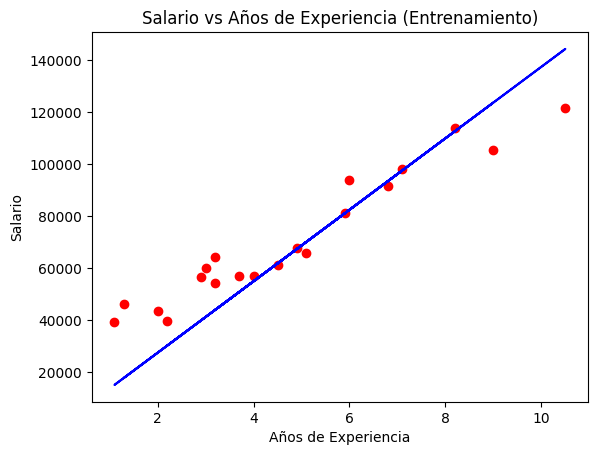

In [ ]:
# Visualizando resultados de Train

plt.scatter(X_train, y_train, color = "red")
plt.plot(X_train, model.predict(X_train), color = "blue")
plt.title("Salario vs Años de Experiencia (Entrenamiento)")
plt.xlabel("Años de Experiencia")
plt.ylabel("Salario")
plt.show()


Ahora grafiquemos los resultados del Test (prueba)


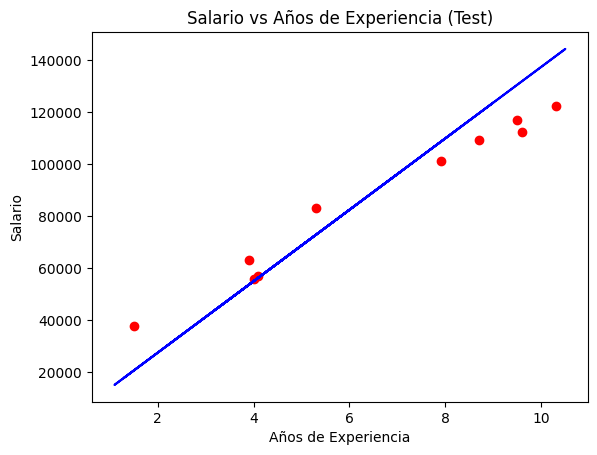

In [ ]:
# Visualizando resultados de Test

plt.scatter(X_test, y_test, color = "red")
plt.plot(X_train, model.predict(X_train), color = "blue")
plt.title("Salario vs Años de Experiencia (Test)")
plt.xlabel("Años de Experiencia")
plt.ylabel("Salario")
plt.show()


El modelo se podría mejorar usando una constante junto con el predictor y ajustando la ecuación : y=b1 * x
